In [23]:
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt

import smoothie
smoothie.suppress_warnings()

In [25]:
#read in data

adata_E2S5_bin20 = ad.read_h5ad("../data/GSM9629362_CS23_E2S5_bin20.h5ad")
adata_E1S1_bin20 = ad.read_h5ad("../data/GSM9629357_CS23_E2S1_bin20.h5ad")

print(adata_E2S5_bin20.shape)
print(adata_E1S1_bin20.shape)

(5764936, 50470)
(5164237, 49848)


In [26]:
#filtering and normalization

sc.pp.filter_cells(adata_E2S5_bin20, min_counts=50)
sc.pp.filter_genes(adata_E2S5_bin20, min_counts=100)
sc.pp.filter_genes(adata_E2S5_bin20, min_cells=10)

sc.pp.normalize_total(adata_E2S5_bin20, target_sum=1e3)
sc.pp.log1p(adata_E2S5_bin20)

print(adata_E2S5_bin20.shape)


(3606469, 28482)


In [27]:
#filtering and normalization

sc.pp.filter_cells(adata_E1S1_bin20, min_counts=50)
sc.pp.filter_genes(adata_E1S1_bin20, min_counts=100)
sc.pp.filter_genes(adata_E1S1_bin20, min_cells=10)

sc.pp.normalize_total(adata_E1S1_bin20, target_sum=1e3)
sc.pp.log1p(adata_E1S1_bin20)

print(adata_E1S1_bin20.shape)

(4110999, 29756)


In [29]:
#smoothing

target_microns = 20.0
micron_to_unit_conversion = 2
sm_adata_E2S5_bin20 = smoothie.run_parallelized_smoothing(
    adata_E2S5_bin20,
    grid_based_or_not=True,
    gaussian_sd=target_microns * micron_to_unit_conversion,
    min_spots_under_gaussian=10
)

#save smoothed data to data folder

sm_adata_E2S5_bin20.write_h5ad("../data/GSM9629362_CS23_E2S5_bin20_smooth.h5ad")

Checking dataset point density...
Fitting grid to tissue coordinates...
Variation in X-direction: 42160.0
Variation in Y-direction: 78320.0
Number of points in fitted grid: 1041214
Gaussian smoothing will run in 36 chunks.
Smoothing chunk: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 
Total runtime for grid-based Gaussian smoothing: 1576.38 seconds.



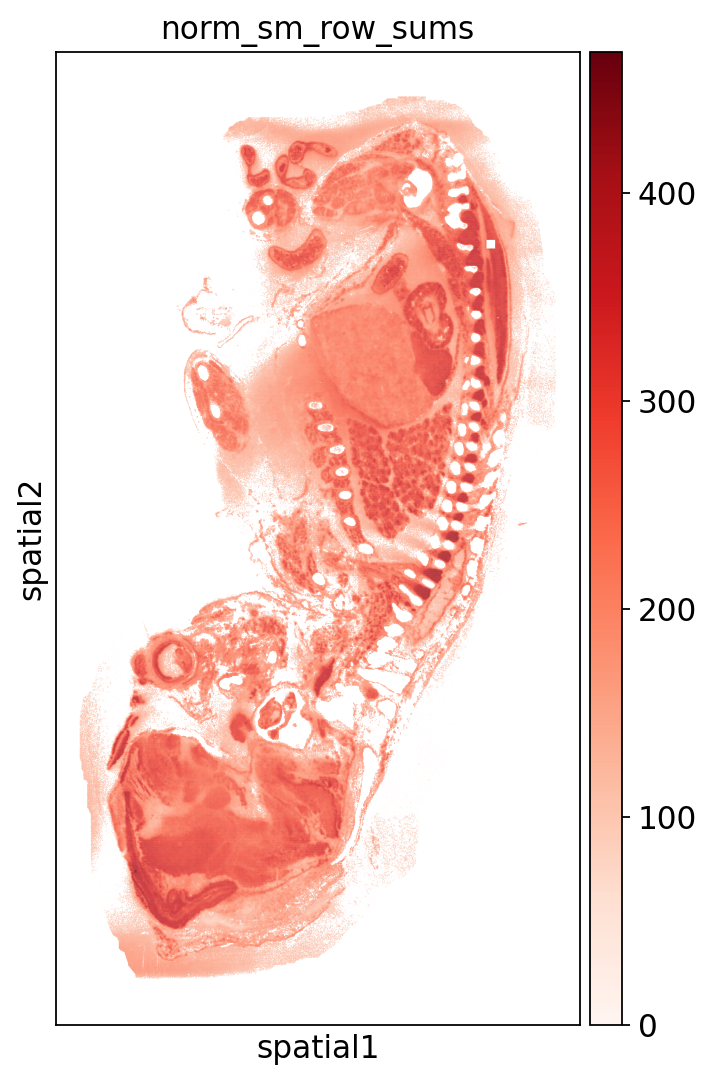

In [33]:
row_sums = np.array(sm_adata_E2S5_bin20.X.sum(axis=1)).flatten()

sm_adata_E2S5_bin20.obs['norm_sm_row_sums'] = row_sums

sc.set_figure_params(figsize=(8, 8))
sc.pl.spatial(sm_adata_E2S5_bin20,
              color='norm_sm_row_sums',
              spot_size=50,
              cmap='Reds',
              )

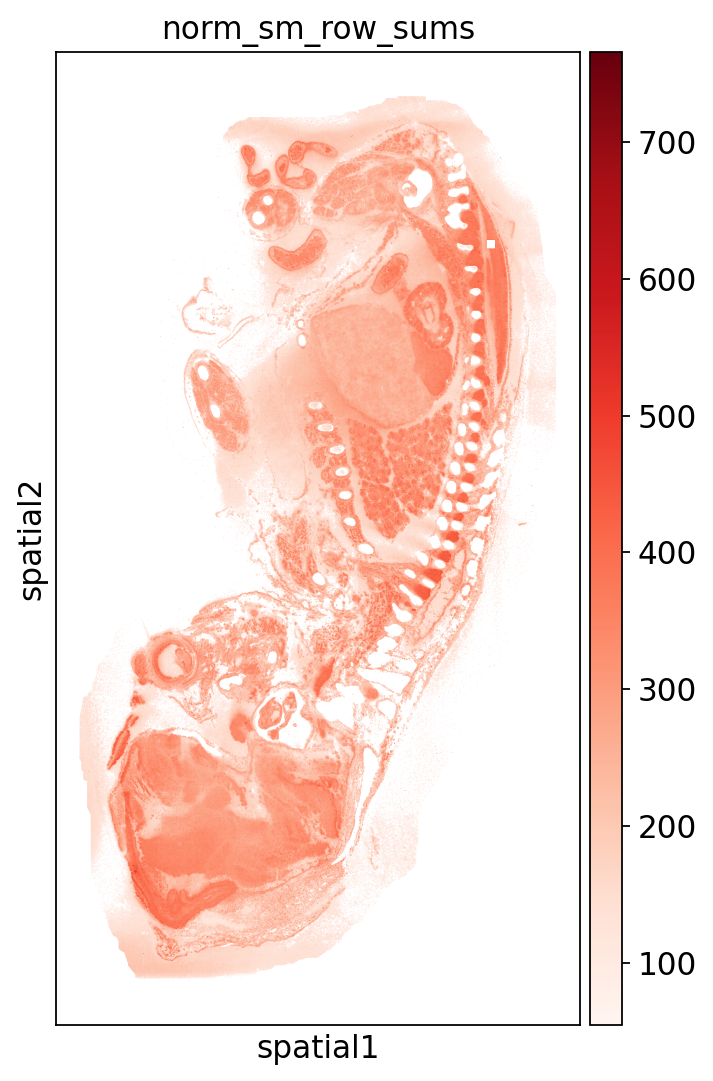

In [35]:
row_sums = np.array(adata_E2S5_bin20.X.sum(axis=1)).flatten()

adata_E2S5_bin20.obs['norm_sm_row_sums'] = row_sums

sc.set_figure_params(figsize=(8, 8))
sc.pl.spatial(adata_E2S5_bin20,
              color='norm_sm_row_sums',
              spot_size=50,
              cmap='Reds',
              )

In [ ]:
#smoothing

target_microns = 20.0
micron_to_unit_conversion = 2
sm_adata_E1S1_bin20 = smoothie.run_parallelized_smoothing(
    adata_E1S1_bin20,
    grid_based_or_not=True,
    gaussian_sd=target_microns * micron_to_unit_conversion,
    min_spots_under_gaussian=10
)

#save smoothed data to data folder

sm_adata_E1S1_bin20.write_h5ad("../data/GSM9629362_CS23_E1S1_bin20_smooth.h5ad")

Checking dataset point density...
Fitting grid to tissue coordinates...
Variation in X-direction: 49460.0
Variation in Y-direction: 70720.0
Number of points in fitted grid: 1186682
Gaussian smoothing will run in 36 chunks.
Smoothing chunk: 1, 2, 3, 

In [ ]:
#compute correlation matrix

pearsonR_mat_E2S5_bin20, pval_mat_E2S5_bin20 = smoothie.compute_correlation_matrix(sm_adata_E2S5_bin20.X)

#save matrices to data folder

np.save(f"../data/SM9629362_CS23_E2S5_bin20_pearsonR.npy", pearsonR_mat_E2S5_bin20)
np.save(f"../data/SM9629362_CS23_E2S5_bin20_pval.npy", pval_mat_E2S5_bin20)
np.save(f"../data/SM9629362_CS23_E2S5_bin20_gene_names.npy", sm_adata_E2S5_bin20.var_names.to_numpy())

In [ ]:
#compute correlation matrix

pearsonR_mat_E1S1_bin20, pval_mat_E1S1_bin20 = smoothie.compute_correlation_matrix(sm_adata_E1S1_bin20.X)

#save matrices to data folder

np.save(f"../data/SM9629362_CS23_E1S1_bin20_pearsonR.npy", pearsonR_mat_E1S1_bin20)
np.save(f"../data/SM9629362_CS23_E1S1_bin20_pval.npy", pval_mat_E1S1_bin20)
np.save(f"../data/SM9629362_CS23_E1S1_bin20_gene_names.npy", sm_adata_E1S1_bin20.var_names.to_numpy())

In [ ]:
#create graphs to determine clustering parameters

smoothie.select_clustering_params(
    gene_names=sm_adata_E2S5_bin20.var_names,
    pearsonR_mat=pearsonR_mat_E2S5_bin20,
    output_folder=None,
    pcc_cutoffs=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    clustering_powers=[1, 3, 5, 7, 9],
    min_genes_for_module=5
)

In [ ]:
#create graphs to determine clustering parameters

smoothie.select_clustering_params(
    gene_names=sm_adata_E1S1_bin20.var_names,
    pearsonR_mat=pearsonR_mat_E1S1_bin20,
    output_folder=None,
    pcc_cutoffs=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    clustering_powers=[1, 3, 5, 7, 9],
    min_genes_for_module=5
)

In [ ]:
#construct network and save to Cytoscape folder

edge_list_E2S5_bin20, node_label_df_E2S5_bin20 = smoothie.make_spatial_network(
    pearsonR_mat=pearsonR_mat_E2S5_bin20, # don't change
    gene_names=sm_adata_E2S5_bin20.var_names, # don't change
    pcc_cutoff=0.4,
    clustering_power=3,
    output_folder='../Cytoscape/E2S5'
)

# Filter node_label_df for only genes within modules of size 2 or more.
modules_df_E2S5_bin20 = node_label_df_E2S5_bin20.groupby('module_label').filter(lambda x: len(x) >= 2)

# Examine modules
modules_df_E2S5_bin20

In [ ]:
#construct network and save to Cytoscape folder

edge_list_E1S1_bin20, node_label_df_E1S1_bin20 = smoothie.make_spatial_network(
    pearsonR_mat=pearsonR_mat_E1S1_bin20, # don't change
    gene_names=sm_adata_E1S1_bin20.var_names, # don't change
    pcc_cutoff=0.4,
    clustering_power=3,
    output_folder='../Cytoscape/E1S1'
)

# Filter node_label_df for only genes within modules of size 2 or more.
modules_df_E1S1_bin20 = node_label_df_E1S1_bin20.groupby('module_label').filter(lambda x: len(x) >= 2)

# Examine modules
modules_df_E1S1_bin20

In [ ]:
#plot the gene modules

smoothie.plot_modules(
    sm_adata_E2S5_bin20,
    node_label_df_E2S5_bin20,
    output_folder='./module_plots_E2S5_bin20',
    min_genes=3, # Minimum number of genes in a module to plot the module
    spot_size=50, # Adjust for optimal visualization
    plots_per_row=10,
    dpi=150 # low resolution here for github, better to choose 300-600!
)

In [ ]:
#plot the gene modules

smoothie.plot_modules(
    sm_adata_E1S1_bin20,
    node_label_df_E1S1_bin20,
    output_folder='./module_plots_E1S1_bin20',
    min_genes=3, # Minimum number of genes in a module to plot the module
    spot_size=50, # Adjust for optimal visualization
    plots_per_row=10,
    dpi=150 # low resolution here for github, better to choose 300-600!
)